In [12]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [13]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'
TEST_YEAR = '2024'
TEST_MONTH = '8'
NUTS2_EL = 'θρακης'

In [14]:
trained_model = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [15]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_{TEST_YEAR}.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(40, 112)


In [16]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL511,2024,1,26.176106,41.222160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.625971,10.638854,16.015594,16.015594,NaN,3.548194,0.489200,3.904642,3.904642,NaN,7.087082,5.564027,9.960118,9.960118,0.407456,16.939561,0.000000,6.966105e-17,0.000000e+00,6.966105e-17,614.661869,53.274510,1.718533,17.000000,19.000000,43.181818,915.026080,39.0,-5.0,44.0,12.666667,21.500000,28.833333,7.000000,612.0,163.0,0.0,111.333305,313.0,0.0,53.0,187.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,9502.0,42054.0,15277.0,66833.0,8736.0,38985.0,18852.0,66573.0,1714.79,3612.0,4034.0,0
1,EL512,2024,1,24.892059,41.169359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.974710,9.745785,16.406468,16.406468,NaN,2.751839,-0.184768,3.470548,3.470548,NaN,6.363274,4.780508,9.938508,9.938508,-0.699663,13.522069,0.000000,-5.551115e-17,-1.443290e-16,0.000000e+00,625.613926,31.000000,1.000000,15.833333,17.000000,42.500000,807.164885,35.0,-5.0,40.0,17.000000,19.333333,26.000000,5.833333,621.0,178.0,0.0,115.864552,300.0,0.0,96.0,190.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,8852.0,35660.0,8919.0,53431.0,8376.0,35256.0,11095.0,54727.0,993.81,2048.0,2252.0,0
2,EL513,2024,1,25.520366,41.111582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.918059,10.437979,16.951550,16.951550,NaN,3.357549,0.503370,4.143554,4.143554,NaN,7.137804,5.470674,10.547552,10.547552,-1.293144,11.920441,0.000000,0.000000e+00,1.146037e-16,3.438110e-16,672.719468,31.000000,1.000000,16.833333,18.666667,41.481481,936.709262,40.0,-5.0,45.0,18.000000,20.500000,28.666667,5.666667,669.0,201.0,0.0,111.047855,307.0,0.0,85.0,215.0,31,20,30,12,9,4,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.0,1.0,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,6748.0,33121.0,10599.0,50468.0,6098.0,33759.0

In [17]:
data_test = encode_cyclical(data_test, 'month', 12)

In [18]:
len(data_test.NUTS3_ID.unique())

5

In [19]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [20]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL511,2024,8,26.176106,41.222160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.558606,8.574981,13.670966,15.738171,24.153030,23.009935,1.385448,5.262983,5.423026,11.262653,29.784271,4.980215,9.466974,10.580598,17.707842,19.314200,42.630800,NaN,0.0,0.0,0.0,247.597694,6270.544118,202.275617,17.000000,19.000000,43.181818,915.026080,39.0,-5.0,44.0,12.666667,21.500000,28.833333,7.000000,612.0,163.0,0.0,111.333305,313.0,0.0,53.0,187.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,9502.0,42054.0,15277.0,66833.0,8736.0,38985.0,18852.0,66573.0,1714.79,3612.0,4034.0,0,-0.866025,-0.5
1,EL512,2024,8,24.892059,41.169359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.191185,7.834355,11.927052,14.937185,23.048017,22.080347,0.107669,3.481793,5.262008,11.293875,27.635766,3.971012,7.704422,10.099597,17.170946,18.790000,39.121250,NaN,0.0,0.0,0.0,215.024880,6174.525000,199.178226,15.833333,17.000000,42.500000,807.164885,35.0,-5.0,40.0,17.000000,19.333333,26.000000,5.833333,621.0,178.0,0.0,115.864552,300.0,0.0,96.0,190.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,8852.0,35660.0,8919.0,53431.0,8376.0,35256.0,11095.0,54727.0,993.81,2048.0,2252.0,0,-0.866025,-0.5
2,EL513,2024,8,25.520366,41.111582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.092419,8.842674,12.980701,16.038085,23.693688,23.254360,1.086363,4.841568,5.500957,11.512516,29.673390,4.964519,8.911135,10.769521,17.603102,18.604032,41.689194,NaN,0.0,0.0,0.0,186.846326,5967.693548,192.506243,16.833333,18.666667,41.481481,936.709262,40.0,-5.0,45.0,18.000000,20.500000,28.666667,5.666667,669.0,201.0,0.0,111.047855,307.0,0.0,85.0,215.0,31,20,30,12,9,4,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.0,1.0,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,6748.0,33121.0,10599.

In [21]:
data_test['rainfall_mean'] = data_test['rainfall_mean'].fillna(0)

In [22]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [23]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [24]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [25]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
3,EL514,2024,8,24.180725,41.300798,0.097154
0,EL511,2024,8,26.176106,41.222160,0.078387
1,EL512,2024,8,24.892059,41.169359,0.068387
2,EL513,2024,8,25.520366,41.111582,0.052397
4,EL515,2024,8,24.438568,40.915602,0.030664


In [26]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [27]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [28]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL51,"Aνατολική Μακεδονία, Θράκη","MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [29]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL511,Έβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,Ξάνθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,Ροδόπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,Δράμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,"Θάσος, Καβάλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [30]:
greece_lau1.head()

,NAME,geometry
0,Ορεστιάδας,"POLYGON ((26.24076 41.73167, 26.24274 41.73022..."
1,Σουφλίου,"POLYGON ((26.17788 41.37548, 26.17812 41.37442..."
2,Αβδήρων,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
3,Αλεξανδρούπολης,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
4,Αρριανών,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."


In [31]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,ISMARIDA LAKE,1865103.9,5520.085,"POLYGON ((25.30862 40.99215, 25.30977 40.99238...",0
1,LEFKOGION RESERVOIR,1091876.6,11878.964,"POLYGON ((23.90767 41.40275, 23.90769 41.40308...",1
2,PLATANOBRISI RESERVOIR,3250727.5,40050.050,"POLYGON ((24.37308 41.36354, 24.37362 41.36409...",2
3,THISAVROS RESERVOIR,6928690.5,34912.035,"POLYGON ((24.28272 41.31770, 24.28317 41.31766...",3
4,GRATINI RESERVOIR,1434043.4,12178.949,"POLYGON ((25.51603 41.16096, 25.51670 41.16102...",4


In [32]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [33]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [34]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL511,2024,8,26.1761,41.2222,0.078387,Έβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,2024,8,24.8921,41.1694,0.068387,Ξάνθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,2024,8,25.5204,41.1116,0.052397,Ροδόπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,2024,8,24.1807,41.3008,0.097154,Δράμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,2024,8,24.4386,40.9156,0.030664,"Θάσος, Καβάλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [35]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

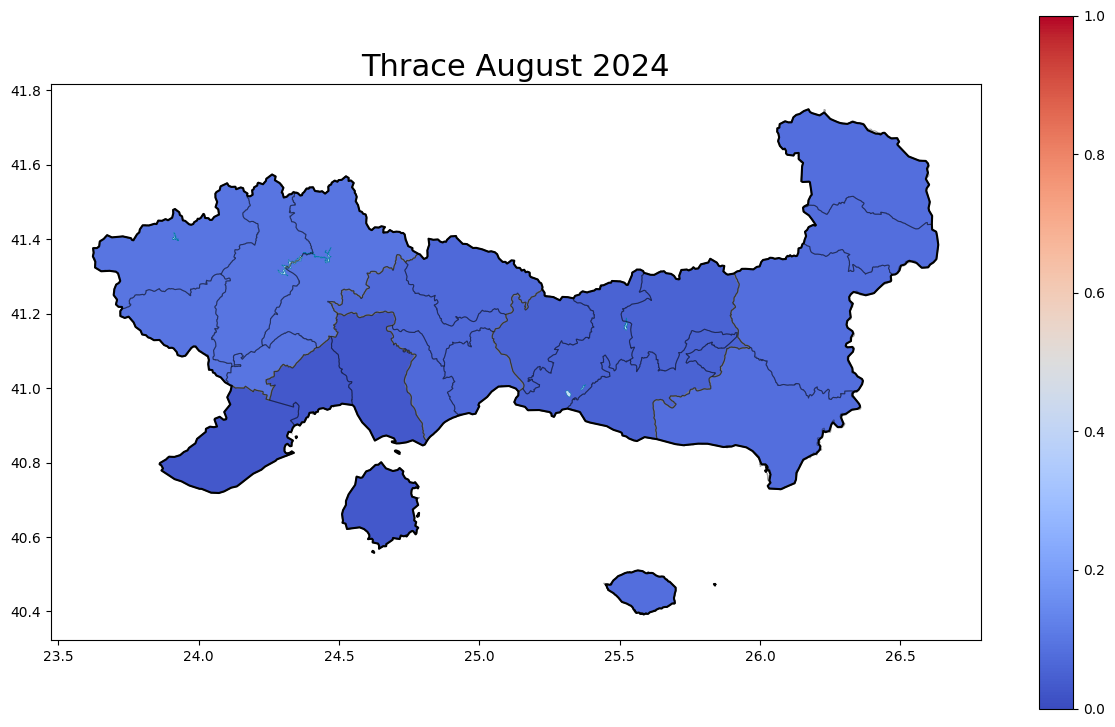

In [36]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [37]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = f'East Macedonia & Thrace June 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [38]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL511,2024,8,26.1761,41.2222,0.078387,Έβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,2024,8,24.8921,41.1694,0.068387,Ξάνθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,2024,8,25.5204,41.1116,0.052397,Ροδόπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,2024,8,24.1807,41.3008,0.097154,Δράμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,2024,8,24.4386,40.9156,0.030664,"Θάσος, Καβάλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."
